In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings

from fontTools.colorLib.builder import populateCOLRv0

warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('USA_Housing.csv')
print(df.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [3]:
df.tail()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316
4999,65510.581804,5.992305,6.792336,4.07,46501.283803,1.298950e+06,"37778 George Ridges Apt. 509\nEast Holly, NV 2..."


In [4]:
df.shape

(5000, 7)

In [5]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [7]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [8]:
df.isnull().sum()

,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Avg. Area Number of Bedrooms,0
Area Population,0
Price,0
Address,0


In [9]:
df.drop("Address", axis=1, inplace=True)

In [10]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
pd.set_option('display.float_format','{:.2f}'.format)

In [13]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.46,5.68,7.01,4.09,23086.80,1059033.56
1,79248.64,6.00,6.73,3.09,40173.07,1505890.91
2,61287.07,5.87,8.51,5.13,36882.16,1058987.99
3,63345.24,7.19,5.59,3.26,34310.24,1260616.81
4,59982.20,5.04,7.84,4.23,26354.11,630943.49


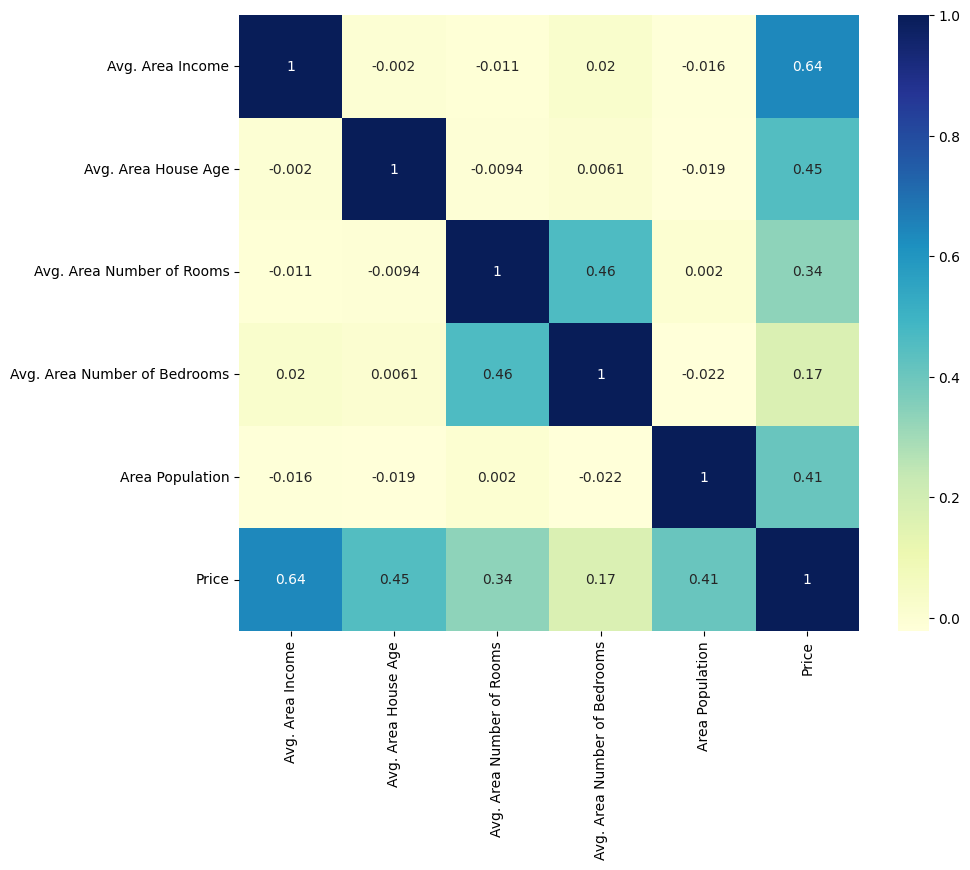

In [14]:
plt.figure(figsize=(10,8))
numeric_df=df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(),annot=True,cmap='YlGnBu')
plt.show()

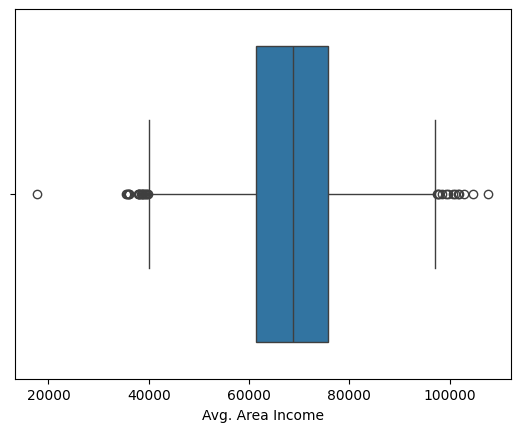

In [15]:
sns.boxplot(x=df["Avg. Area Income"])
plt.show()

In [16]:
Q1=df["Avg. Area Income"].quantile(0.25)
Q3=df["Avg. Area Income"].quantile(0.75)
IQR=Q3 - Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

df=df[(df["Avg. Area Income"]>=lower) & (df["Avg. Area Income"]<=upper)]

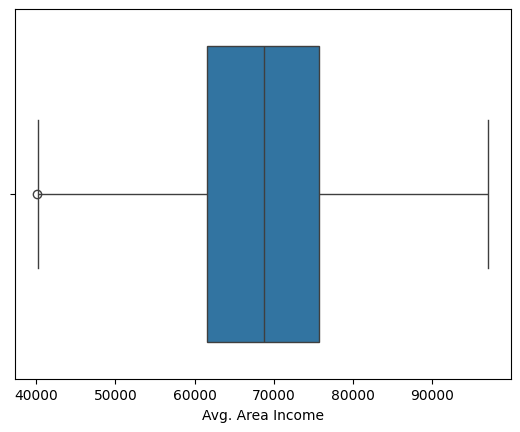

In [17]:
sns.boxplot(x=df["Avg. Area Income"])
plt.show()

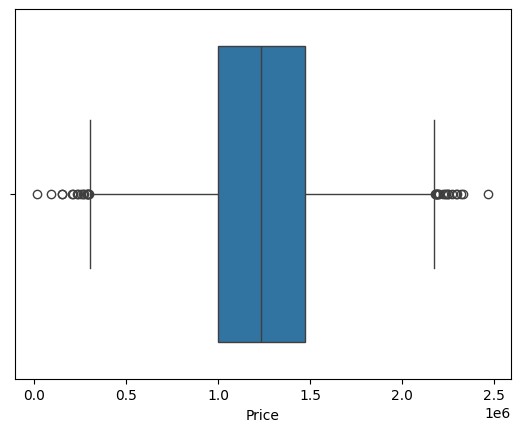

In [18]:
sns.boxplot(x=df["Price"])
plt.show()

In [19]:
Q1=df["Price"].quantile(0.25)
Q3=df["Price"].quantile(0.75)
IQR=Q3 - Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df=df[(df["Price"]>=lower) & (df["Price"]<=upper)]


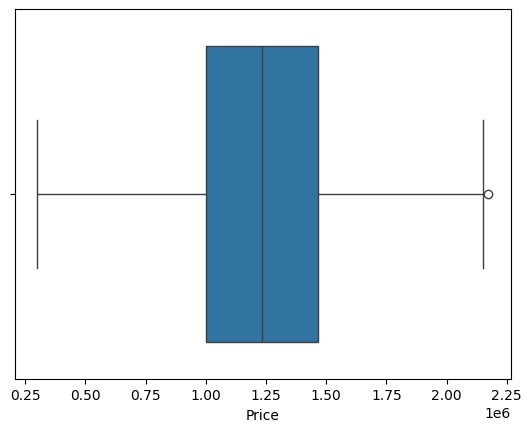

In [20]:
sns.boxplot(x=df["Price"])
plt.show()

# SLR

In [21]:
X=df[["Avg. Area Income"]]
y=df["Price"]

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression

slr_model=LinearRegression()
slr_model.fit(X_train,y_train)

LinearRegression()

In [24]:
y_pred=slr_model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

print("Simple Linear Regression Results")
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("Root Mean Squared Error:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2 Score:",r2_score(y_test,y_pred))

Simple Linear Regression Results
Mean Absolute Error: 216087.7143550425
Mean Squared Error: 70880962067.4512
Root Mean Squared Error: 266234.7874855035
R2 Score: 0.3983053580403858


In [26]:
print("Intercept:",slr_model.intercept_)
print("Slope:",slr_model.coef_[0])

Intercept: -174255.61105124326
Slope: 20.479085073124374


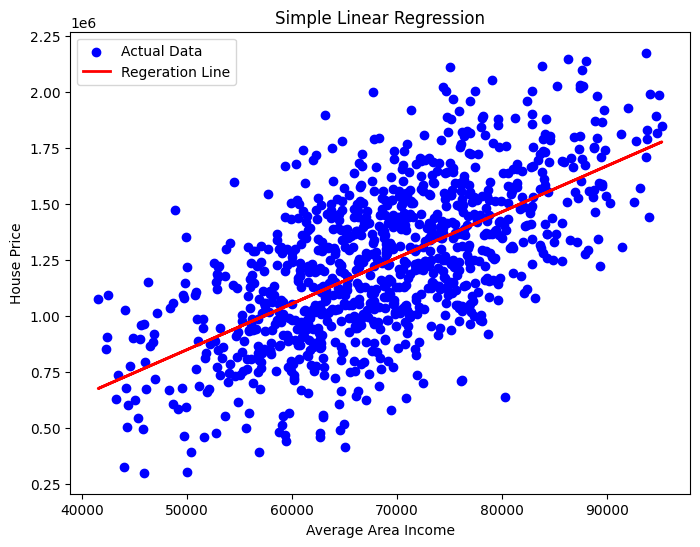

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(X_test,y_test,color='blue',label='Actual Data')
plt.plot(X_test,y_pred,color='red',linewidth=2,label='Regeration Line')

plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

In [28]:
income=float(input("Enter Average Area Income:"))

new_data=np.array([[income]])
prediction=slr_model.predict(new_data)
print("Predicted House Price = ${:.2f}".format(prediction[0]))


Enter Average Area Income:24000
Predicted House Price = $317242.43


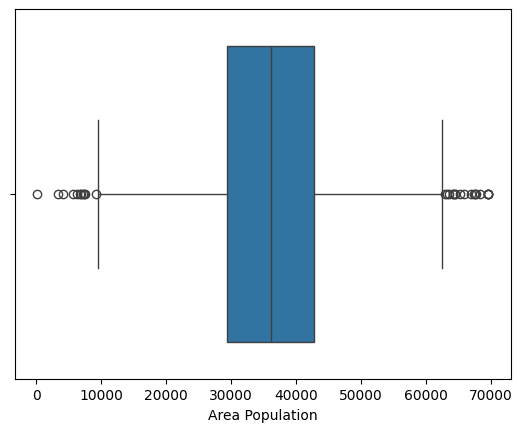

In [29]:
sns.boxplot(x=df["Area Population"])
plt.show()

# MLR

In [30]:
X=df.drop(["Price"],axis=1)
y=df["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
mlr=LinearRegression()
mlr.fit(X_train,y_train)

LinearRegression()

In [32]:
coef=pd.DataFrame(
    mlr.coef_,
    X.columns,
    columns=['Coefficient']
)
coef

,Coefficient
Avg. Area Income,21.53
Avg. Area House Age,165086.64
Avg. Area Number of Rooms,121071.09
Avg. Area Number of Bedrooms,1327.60
Area Population,14.98


In [33]:
y_pred=mlr.predict(X_test)

In [34]:
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2:",r2_score(y_test,y_pred))

MAE: 78456.94223111961
MSE: 9643840322.406485
RMSE: 98203.0565838278
R2: 0.9181353232143747


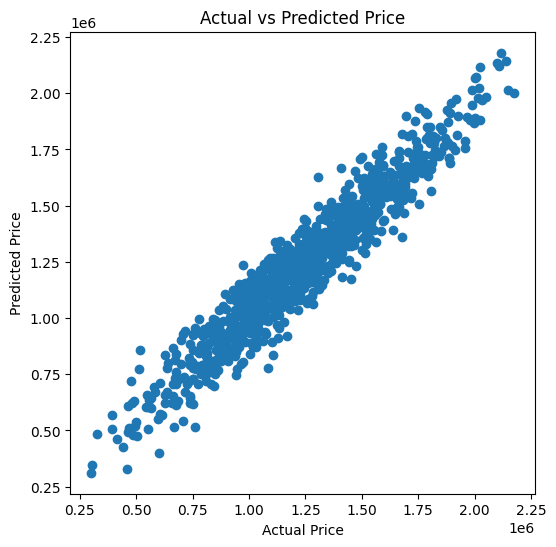

In [35]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [36]:
income=float(input("Enter Average Area Income:"))
house_age=float(input("Enter Average House Age:"))
rooms=float(input("Enter Average Rooms:"))
bedrooms=float(input("Enter Average Bedrooms:"))
population=float(input("Enter Average Population:"))
test_input=np.array([[income,house_age,rooms,bedrooms,population]])
prediction=mlr.predict(test_input)
print("Predicted House Price = ${:.2f}".format(prediction[0]))


Enter Average Area Income:24000
Enter Average House Age:20
Enter Average Rooms:2
Enter Average Bedrooms:1
Enter Average Population:20000
Predicted House Price = $1735839.61


# Ridge Regression

In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train,y_train)
ridge_pred=ridge.predict(X_test)
print("Default Ridge R2 Score:",r2_score(y_test,ridge_pred))

Default Ridge R2 Score: 0.9181377871832105


In [39]:
param_grid={'alpha':[0.001,0.01,0.1,1,10,100],}

In [40]:
grid_ridge=GridSearchCV(estimator=Ridge(),param_grid=param_grid,scoring='r2',cv=5)

In [41]:
grid_ridge.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [42]:
print("Best Alpha: ", grid_ridge.best_params_)


Best Alpha:  {'alpha': 1}


In [43]:
print(grid_ridge.best_score_)

0.9103899645949152


In [44]:
best_ridge=grid_ridge.best_estimator_
ridge_pred=grid_ridge.predict(X_test)

In [45]:
print("MSE:",mean_squared_error(y_test,ridge_pred))
print("MAE:",mean_absolute_error(y_test,ridge_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,ridge_pred)))
print("R2:",r2_score(y_test,ridge_pred))


MSE: 9643550061.417933
MAE: 78456.01211596081
RMSE: 98201.57871143382
R2: 0.9181377871832105


# Lasso Regression

In [46]:
from sklearn.linear_model import Lasso
param_grid={'alpha':[0.001,0.01,0.1,1,10,100],}

In [47]:
grid_lasso=GridSearchCV(Lasso(max_iter=5000),param_grid=param_grid,cv=5)
grid_lasso.fit(X_train,y_train)


GridSearchCV(cv=5, estimator=Lasso(max_iter=5000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

In [48]:
print(grid_lasso.best_params_)

{'alpha': 0.001}


In [49]:
lasso_pred=grid_lasso.predict(X_test)
print(r2_score(y_test,lasso_pred))

0.9181353232692439
